# Annealed Sinkhorn for Optimal Transport

This tutorial explores how *annealing* the regularization parameter $\varepsilon$ of Sinkhorn's algorithm can improve the speed-accuracy trade-off in entropy-regularized optimal transport. The experiments are inspired by {cite}`chizat:24`.

We start from fixed-$\varepsilon$ Sinkhorn baselines and build up progressively: first using the native geometric scheduler {class}`~ott.geometry.epsilon_scheduler.Epsilon` from OTT-JAX, then polynomial schedules that better match the convergence theory, and finally a debiased variant that corrects the relaxation error introduced by temperature changes. Along the way, we identify the practical optimal schedule exponent and show what happens when the annealing conditions are violated.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from ott.geometry import pointcloud, epsilon_scheduler      
from ott.problems.linear import linear_problem
from ott.solvers import linear
from ott.solvers.linear import sinkhorn


jax.config.update("jax_enable_x64", True)

## Sinkhorn's algorithm in a nutshell

**Setup.** Let $a \in \Delta_n^*$ and $b \in \Delta_m^*$ be two probability vectors, referred to as *marginals* in OTT-JAX, supported on point clouds $\{x_i\}_{i=1}^n$ and $\{y_j\}_{j=1}^m$ in $\mathbb{R}^d$. In OTT-JAX, these are encapsulated together with a cost matrix $C \in \mathbb{R}^{n \times m}_+$ (e.g., $C_{ij} = \|x_i - y_j\|^2$) into a `PointCloud` object.

**Optimal transport problem.** Finding the cheapest way to transport mass $a$ onto $b$ amounts to solving:

$$\operatorname{OT}(a, b) = \min_{P \in U(a,b)} \langle C, P \rangle$$

where $U(a,b) = \bigl\{P \in \mathbb{R}^{n \times m}_+ : P\mathbf{1}_m = a,\; P^\top\mathbf{1}_n = b\bigr\}$ is the set of *transport plans* with prescribed marginals. Solving this exactly requires super-cubic time in $n$, which is prohibitive at scale.

**Entropy-regularized OT.** Sinkhorn's algorithm instead solves a smoothed surrogate, adding an entropic penalty parameterized by $\varepsilon > 0$, the `epsilon` argument passed to any `PointCloud` in OTT-JAX:

$$\operatorname{OT}_\varepsilon(a,b) = \min_{P \in U(a,b)} \langle C, P \rangle
+ \varepsilon\,\operatorname{KL}(P \,\|\, P^{\mathrm{ref}})$$

where $\operatorname{KL}(P \| Q) = \sum_{i,j} P_{ij}\log\frac{P_{ij}}{Q_{ij}}- P_{ij} + Q_{ij}$ and $P^{\mathrm{ref}} = \frac{1}{nm}\mathbf{1}_n\mathbf{1}_m^\top$ by convention.

> **Convention: $\varepsilon$ vs $\beta$.** This tutorial uses $\varepsilon > 0$ to match OTT-JAX's `epsilon` argument. The annealing literature often uses the *inverse temperature*  > $\beta = 1/\varepsilon$ instead. A small `epsilon` (large $\beta$) means little regularization — the solution is close to $\operatorname{OT}(a,b)$, but convergence is slow. A large > `epsilon` > (small $\beta$) means fast convergence but a large regularization bias. **This is the fundamental speed-accuracy trade-off that motivates annealing.**

**Gibbs kernel and solution structure.** The unique minimizer of $\operatorname{OT}_\varepsilon$ has the form:

$$P^* = \mathrm{diag}(u^*)\, K\, \mathrm{diag}(v^*)$$

for some $u^* \in (\mathbb{R}^*_+)^n$, $v^* \in (\mathbb{R}^*_+)^m$, where $K_{ij} = \exp(-C_{ij} / \varepsilon)$ is the *Gibbs kernel* (accessible as `geom.kernel_matrix` in OTT-JAX).

**Sinkhorn iterations.** Starting from $v^{(0)} = \mathbf{1}_m$, the scaling vectors are updated by alternating projections onto the marginal constraints:

$$u^{(t)} \leftarrow a \oslash \bigl(K\, v^{(t-1)}\bigr), \qquad v^{(t)} \leftarrow b \oslash \bigl(K^\top u^{(t)}\bigr)$$

where $\oslash$ denotes elementwise division. By default, OTT-JAX performs these updates in log-domain via `log-sum-exp` operations (`lse_mode=True`), which avoids numerical underflow when `epsilon` is small. The primal iterate is $P^{(t)} = \mathrm{diag}(u^{(t)}) K\, \mathrm{diag}(v^{(t)})$, and convergence is monitored via the marginal violation error `out.errors`.

## Baseline: fixed-ε Sinkhorn

We sample two point clouds $x \in \mathbb{R}^{300 \times 2}$ and
$y \in \mathbb{R}^{300 \times 2}$, pass them to a
{class}`~ott.geometry.pointcloud.PointCloud` with a fixed $\varepsilon$,
and record the OT cost and marginal violation error across a range of
regularization values. This builds the **Pareto front** that annealed
variants will later try to beat.

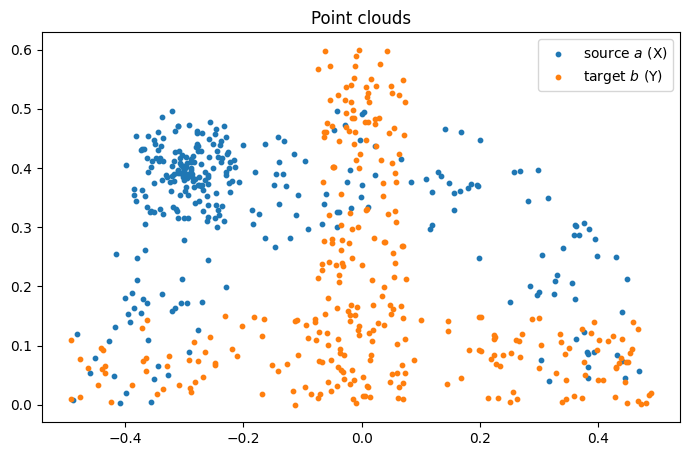

In [3]:
rng = jax.random.key(1)  
rng, r1, r2, r3, r4, r5, r6 = jax.random.split(rng, 7)

#Source X
# Half-moon (m=150) : angles in [0, π], radius in [0.3, 0.5] 
m1 = 150
ang1 = jax.random.uniform(r1, (m1,)) * jnp.pi
rad1 = jax.random.uniform(r2, (m1,)) * 0.2 + 0.3
X1   = jnp.stack([rad1 * jnp.cos(ang1), rad1 * jnp.sin(ang1)], axis=1)

# Small blob (m=150) : angles in [0, 2π], radius in [0, 0.1], centered at (-0.3, 0.4)
m2   = 150
ang2 = jax.random.uniform(r3, (m2,)) * 2 * jnp.pi
rad2 = jax.random.uniform(r4, (m2,)) * 0.1
X2   = jnp.stack([rad2 * jnp.cos(ang2) - 0.3, rad2 * jnp.sin(ang2) + 0.4], axis=1)

x = jnp.concatenate([X1, X2], axis=0)   # (300, 2)

#Target Y 
# Horizontal rectangle (n=150) : x ∈ [-0.5, 0.5], y ∈ [0, 0.15]
n1 = 150
Y1 = jnp.stack([
    jax.random.uniform(r5, (n1,)) - 0.5,
    jax.random.uniform(r6, (n1,)) * 0.15,
], axis=1)

# Vertical rectangle (n=150) : x ∈ [-0.075, 0.075], y ∈ [0, 0.6]
rng, r7, r8 = jax.random.split(rng, 3)
n2 = 150
Y2 = jnp.stack([
    (jax.random.uniform(r7, (n2,)) - 0.5) * 0.15,
    jax.random.uniform(r8, (n2,)) * 0.6,
], axis=1)

y = jnp.concatenate([Y1, Y2], axis=0)   # (300, 2)

#Marginals + normalised cost matrix  
a = jnp.ones(x.shape[0]) / x.shape[0]
b = jnp.ones(y.shape[0]) / y.shape[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x[:, 0], x[:, 1], s=10, label="source $a$ (X)")
ax.scatter(y[:, 0], y[:, 1], s=10, label="target $b$ (Y)")
ax.set_aspect("equal")
ax.legend()
ax.set_title("Point clouds")
plt.tight_layout()
plt.show()

We approximate the **true** OT cost $\operatorname{OT}(a,b)$ by running {func}`~ott.solvers.linear.solve` at $\varepsilon = 10^{-4}$ with a generous iteration budget. The attribute `primal_cost` of the returned {class}`~ott.solvers.linear.sinkhorn.SinkhornOutput` gives $\langle C, P^\star_\varepsilon \rangle$, the transport cost of the entropic plan, without the entropic penalty term. As $\varepsilon \to 0$, $P^\star_\varepsilon$ converges to the unregularized OT plan, so this serves as a tight approximation of $\operatorname{OT}(a,b)$.

In [4]:
geom_ref = pointcloud.PointCloud(x, y, epsilon=1e-4)
out_ref  = linear.solve(geom_ref, a=a, b=b, max_iterations=50_000)
OT_ref   = float(out_ref.primal_cost)
print(f"Reference OT(a, b) ≈ {OT_ref:.6f}  (converged: {out_ref.converged})")

Reference OT(a, b) ≈ 0.078080  (converged: True)


We track two metrics as a function of iteration count $t$.

The **marginal violation error** `out.errors` measures how far the current iterate $P^{(t)}$ is from satisfying the marginal constraints:

$$\operatorname{err}(t) = \|P^{(t)}\mathbf{1}_m - a\|_1 + \|(P^{(t)})^\top\mathbf{1}_n - b\|_1.$$

The **OT suboptimality** measures the transport cost after projecting $P^{(t)}$ onto $U(a,b)$ via Altschuler's rounding:

$$\langle C,\, \widehat{P}^{(t)}\rangle - \operatorname{OT}(a, b), \qquad \widehat{P}^{(t)} = \operatorname{proj}_{U(a,b)}(P^{(t)}).$$

In [5]:
def altschuler_round(P: jax.Array, a: jax.Array, b: jax.Array) -> jax.Array:
    """Project a non-negative matrix onto U(a, b) in O(nm) time."""
    r1 = P.sum(axis=1)
    F  = P * (jnp.minimum(a, r1) / r1)[:, None]
    r2 = F.sum(axis=0)
    G  = F * (jnp.minimum(b, r2) / r2)[None, :]
    err_a = a - G.sum(axis=1)
    err_b = b - G.sum(axis=0)
    return G + jnp.outer(err_a, err_b) / err_b.sum()


def ot_suboptimality(out, geom: pointcloud.PointCloud, a: jax.Array, b: jax.Array, ot_ref: float) -> float:
    """Return ⟨C, proj_{U(a,b)}(P*)⟩ − OT(a, b) for the converged plan P* = out.matrix."""
    P_rounded = altschuler_round(out.matrix, a, b)
    return float(jnp.sum(geom.cost_matrix * P_rounded)) - ot_ref

These two metrics capture different aspects of the $\varepsilon$ trade-off:

- **Small $\varepsilon$**: Sinkhorn converges slowly (many iterations), but once converged, the rounding $\widehat{P}^{(t)}$ is close to the true OT plan → **low suboptimality, high iteration cost**.
- **Large $\varepsilon$**: Sinkhorn converges in very few iterations, but the entropy bias makes $\langle C, \widehat{P}\rangle \gg \text{OT}(a,b)$ → **fast but inaccurate**.

The Pareto front below encodes the best achievable trade-off over all fixed-$\varepsilon$ runs.

We wrap {func}`~ott.solvers.linear.solve` with `inner_iterations=1` to record
the marginal error at **every** Sinkhorn iteration in `out.errors` rather than
every 10 (the default). We sweep over
$\varepsilon \in \{5\times10^{-1}, \ldots, 1\times10^{-3}\}$ and record the
iteration count and OT suboptimality at convergence.

In [6]:
def run_sinkhorn(eps: float, x, y, a, b, max_iterations: int = 5_000):
    """Run Sinkhorn at fixed epsilon, recording the marginal error at every iteration."""
    geom = pointcloud.PointCloud(x, y, epsilon=eps)
    out  = linear.solve(geom, a=a, b=b,inner_iterations=1,max_iterations=max_iterations)
    return out, geom


epsilons = [5e-1, 2e-1, 1e-1, 5e-2, 2e-2, 1e-2, 5e-3, 2e-3, 1e-3]
fixed_results  = {}

for eps in epsilons:
    out, geom = run_sinkhorn(eps, x, y, a, b)
    subopt    = ot_suboptimality(out, geom, a, b, OT_ref)
    n_iters   = int(jnp.sum(out.errors >= 0))  # filter -1 padding
    fixed_results[eps] = {"out": out, "geom": geom, "subopt": subopt, "n_iters": n_iters}
    print(f"ε = {eps:.0e} | iters = {n_iters:5d} | suboptimality = {subopt:.2e}")

ε = 5e-01 | iters =     2 | suboptimality = 9.94e-02
ε = 2e-01 | iters =     5 | suboptimality = 6.83e-02
ε = 1e-01 | iters =    10 | suboptimality = 4.26e-02
ε = 5e-02 | iters =    23 | suboptimality = 2.58e-02
ε = 2e-02 | iters =    61 | suboptimality = 1.30e-02
ε = 1e-02 | iters =   122 | suboptimality = 7.31e-03
ε = 5e-03 | iters =   240 | suboptimality = 3.93e-03
ε = 2e-03 | iters =   581 | suboptimality = 1.66e-03
ε = 1e-03 | iters =  1122 | suboptimality = 8.76e-04


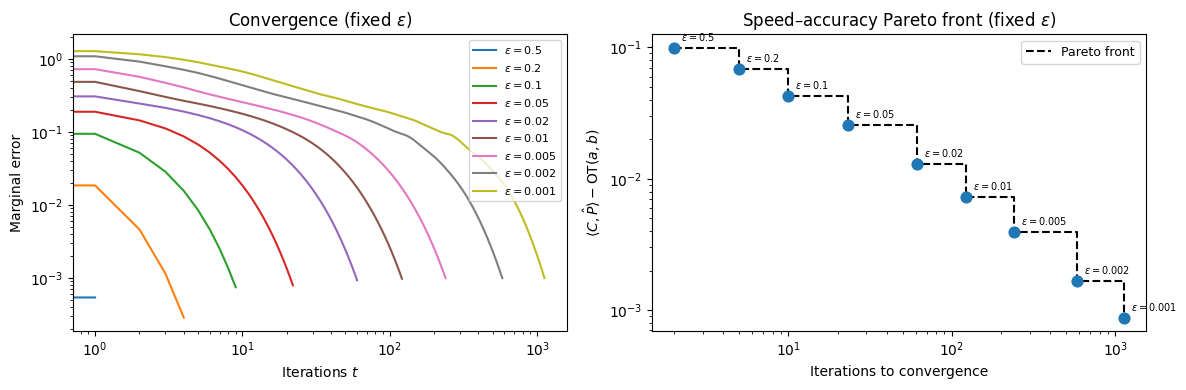

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for eps in epsilons:
    errs = fixed_results[eps]["out"].errors
    errs = errs[errs >= 0]
    ax.plot(errs, linewidth=1.5, label=rf"$\varepsilon={eps}$")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Iterations $t$")
ax.set_ylabel("Marginal error")
ax.set_title(r"Convergence (fixed $\varepsilon$)")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
suboptimals = [fixed_results[eps]["subopt"] for eps in epsilons]
n_iters_all = [fixed_results[eps]["n_iters"] for eps in epsilons]
ax.scatter(n_iters_all, suboptimals, s=60, zorder=5)
for eps, ni, so in zip(epsilons, n_iters_all, suboptimals):
    ax.annotate(rf"$\varepsilon={eps}$", (ni, so),
                textcoords="offset points", xytext=(5, 5), fontsize=7)

sorted_pairs = sorted(zip(n_iters_all, suboptimals))
pareto_x, pareto_y = zip(*sorted_pairs)
ax.step(pareto_x, np.minimum.accumulate(pareto_y), where="post",
        linestyle="--", color="black", linewidth=1.5, label="Pareto front")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Iterations to convergence")
ax.set_ylabel(r"$\langle C, \hat{P}\rangle - \mathrm{OT}(a,b)$")
ax.set_title(r"Speed–accuracy Pareto front (fixed $\varepsilon$)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

The convergence curves (left) display the characteristic profile of Sinkhorn: a slow initial phase followed by an accelerating descent once the iterates enter the linear convergence regime. The spectral gap grows with $\varepsilon$: at $\varepsilon = 0.5$ Sinkhorn converges in a single iteration, while at $\varepsilon = 0.001$ it requires over $10^3$ iterations to reach a comparable marginal error.

The speed–accuracy Pareto front (right) makes the trade-off explicit: each point corresponds to one fixed-$\varepsilon$ run, placed at its convergence cost (iterations) and its residual suboptimality after rounding. No single  $\varepsilon$ dominates everywhere — large $\varepsilon$ is cheap but biased, small $\varepsilon$ is accurate but slow.


The goal of *Annealed Sinkhorn* is for a **single run** to trace — or beat — this
entire front.

## Annealed Sinkhorn

Instead of a fixed $\varepsilon$, *Annealed Sinkhorn* uses a non-decreasing inverse temperature sequence $(\beta_t)_{t \geq 1}$ with $\beta_t = 1/\varepsilon_t$:
we start warm (large $\varepsilon$) for a fast coarse solution, then cool down progressively, reusing the current iterate as a warm start at each step.

The suboptimality at iteration $t$ decomposes as:

$$\langle C, \widehat{P}_t \rangle - \mathrm{OT}(a,b) \;\lesssim\; \underbrace{\beta_t^{-1}}_{\text{entropic error}} \;+\; \underbrace{\beta_t - \beta_{t-1}}_{\text{relaxation error}}$$

The entropic error decreases as $\beta_t$ grows; the relaxation error penalizes schedules that cool too fast — annealing too aggressively shocks the iterate away from the regularization path. A good schedule must balance both terms. 

We parametrize all schedules with a common starting point $\beta_0 = 10 / \|C\|_{\mathrm{osc}}$, where $\|C\|_{\mathrm{osc}} = \max C - \min C$ is the oscillation of the cost matrix.
This normalization ensures that $\varepsilon_0 = 1/\beta_0$ is always of the same order as the cost scale, regardless of the problem instance. We then compare two families: geometric schedules driven by OTT-JAX's native `Epsilon` scheduler, and polynomial schedules that match the convergence theory.

In [26]:
_annealed_solver = sinkhorn.Sinkhorn(inner_iterations=1, max_iterations=1, threshold=0.0)


def annealed_sinkhorn_ott(x, y, a, b, eps_sched, T: int, ot_ref=None):
    """Run T steps of annealed Sinkhorn via lax.scan with potential rescaling on epsilon change."""
    ot_ref_val = float(ot_ref) if ot_ref is not None else 0.0
    eps_seq    = jnp.array([float(eps_sched(t)) for t in range(T)])

    def step(carry, idx):
        f, g, eps_prev = carry
        eps_t = eps_seq[idx]

        #Rescale potentials to new epsilon before warm start
        f = f * eps_t / eps_prev
        g = g * eps_t / eps_prev

        geom = pointcloud.PointCloud(x, y, epsilon=eps_t)
        prob = linear_problem.LinearProblem(geom, a=a, b=b)
        out  = _annealed_solver(prob, init=(f, g))
        f, g = out.f, out.g

        P      = geom.transport_from_potentials(f, g)
        P_hat  = altschuler_round(P, a, b)
        err    = (jnp.abs(P.sum(axis=1) - a).sum() + jnp.abs(P.sum(axis=0) - b).sum())
        subopt = jnp.sum(geom.cost_matrix * P_hat) - ot_ref_val

        return (f, g, eps_t), {"eps": eps_t, "margin_err": err, "subopt": subopt}

    f0   = jnp.zeros(x.shape[0])
    g0   = jnp.zeros(y.shape[0])
    eps0 = eps_seq[0]

    _, metrics = jax.jit(lambda carry, xs: jax.lax.scan(step, carry, xs))((f0, g0, eps0), jnp.arange(T))

    records = [{"t": t + 1, **{k: float(v[t]) for k, v in metrics.items()}} for t in range(T)]
    return records

### Geometric schedules via OTT-JAX `Epsilon`

The natural starting point is the `Epsilon` scheduler built into OTT-JAX,
which implements a geometric decay of the regularization parameter from
$\varepsilon_0$ to $\varepsilon_{\mathrm{end}}$ over $T$ steps.

$$
\varepsilon_t = \varepsilon_{\text{end}} \cdot \texttt{init} \cdot \texttt{decay}^t,
\qquad
\texttt{init} = \frac{\varepsilon_{\text{start}}}{\varepsilon_{\text{end}}},
\qquad
\texttt{decay} = \left(\frac{\varepsilon_{\text{end}}}{\varepsilon_{\text{start}}}\right)^{1/(T-1)}.
$$

In OTT-JAX this is implemented as

```python
epsilon_scheduler.Epsilon(
    target=eps_end,
    init=eps_start / eps_end,
    decay=(eps_end / eps_start) ** (1.0 / max(T - 1, 1)),
)
```

so that ε₀ = target * init = eps_start and ε_{T-1} ≈ eps_end.

We evaluate three schedules with common starting point $\varepsilon_0 = \|C\|_{\mathrm{osc}} / 10$ from the previous section, varying only the decay rate $r$:

- `slow`: strong initial regularization, very gradual decay.
- `medium`: balanced speed and stability.
- `fast`: aggressive cooling, higher relaxation error.

In [ ]:
def make_epsilon_schedule(eps_start: float, eps_end: float, T: int):
    """Build an OTT-JAX Epsilon scheduler decaying geometrically from eps_start to eps_end in T steps."""
    #eps(t) = target * init * decay^t
    init  = eps_start / eps_end
    decay = (eps_end / eps_start) ** (1.0 / max(T - 1, 1))
    return epsilon_scheduler.Epsilon(target=eps_end, init=init, decay=decay)

In [10]:
# Oscillation of the cost matrix; sets the base regularization scale
geom_full = pointcloud.PointCloud(x, y)
C         = geom_full.cost_matrix
c_osc     = float(C.max() - C.min())
eps_0     = c_osc / 10.0
beta_0    = 1.0 / eps_0
print(f"||C||_osc = {c_osc:.4f} -> eps_0 = {eps_0:.4f}")

T = 1000  # number of outer iterations

sched_slow   = make_epsilon_schedule(eps_start=eps_0, eps_end=eps_0 / 4.0,  T=T)
sched_medium = make_epsilon_schedule(eps_start=eps_0, eps_end=eps_0 / 10.0, T=T)
sched_fast   = make_epsilon_schedule(eps_start=eps_0, eps_end=eps_0 / 50.0, T=T)

||C||_osc = 0.9539 -> eps_0 = 0.0954


In [11]:
schedules = {
    "slow":   sched_slow,
    "medium": sched_medium,
    "fast":   sched_fast,
}

records = {
    name: annealed_sinkhorn_ott(x, y, a, b, eps_sched=sched, T=T, ot_ref=OT_ref)
    for name, sched in schedules.items()
}

annealed_results = {
    name: {
        "iters":  np.array([r["t"]          for r in recs]),
        "subopt": np.array([r["subopt"]      for r in recs]),
        "merr":   np.array([r["margin_err"]  for r in recs]),
    }
    for name, recs in records.items()
}

print("Final subopt — " + " | ".join(f"{name}: {annealed_results[name]['subopt'][-1]:.2e}" for name in schedules))

Final subopt — slow: 1.53e-02 | medium: 8.98e-03 | fast: 1.43e-02


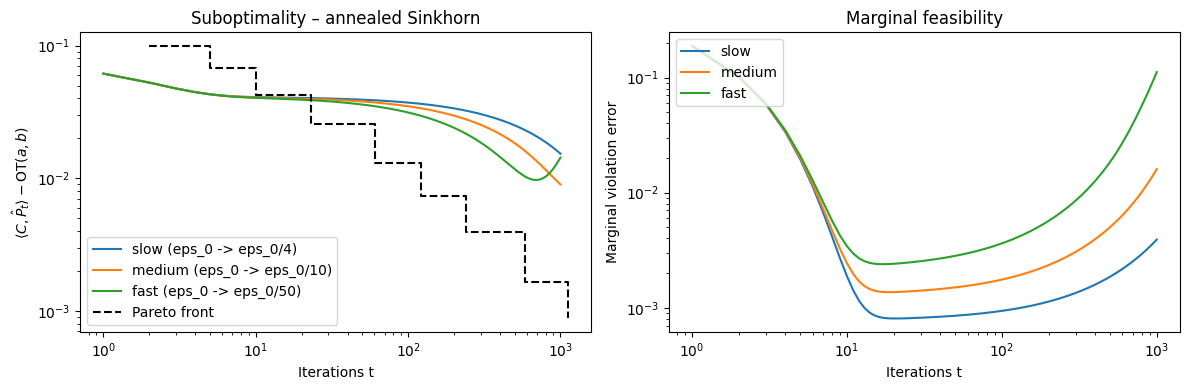

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for name, label in [("slow", "slow (eps_0 -> eps_0/4)"),
                    ("medium", "medium (eps_0 -> eps_0/10)"),
                    ("fast", "fast (eps_0 -> eps_0/50)")]:
    ax.loglog(annealed_results[name]["iters"], annealed_results[name]["subopt"], label=label)
ax.step(pareto_x, np.minimum.accumulate(pareto_y), where="post", #Built in Cell 12 — re-run if needed
        linestyle="--", color="black", linewidth=1.5, label="Pareto front")
ax.set_xlabel("Iterations t")
ax.set_ylabel(r"$\langle C,\hat P_t\rangle - \mathrm{OT}(a,b)$")
ax.set_title("Suboptimality – annealed Sinkhorn")
ax.legend(loc="lower left")

ax = axes[1]
for name in ["slow", "medium", "fast"]:
    ax.loglog(annealed_results[name]["iters"], annealed_results[name]["merr"], label=name)
ax.set_xlabel("Iterations t")
ax.set_ylabel("Marginal violation error")
ax.set_title("Marginal feasibility")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Left panel.** The three geometric schedules show contrasting behaviours. `fast` reaches a low suboptimality early but then diverges, the relaxation error eventually dominates and the iterates are pushed away from the solution. `slow` and `medium` both decrease monotonically throughout the run, with `medium` finishing lower than `slow` : a more aggressive schedule can yield better final accuracy, provided the relaxation error remains controlled. None of the three approaches the Pareto front.

**Right panel.** The marginal feasibility confirms this picture: only `fast` eventually explodes, while `slow` and `medium` keep improving — `medium` converging to a lower floor than `slow`. This is the relaxation error made concrete: for a geometric schedule $\varepsilon_t = \varepsilon_0 r^t$ with $r < 1$, the kernel shift at each step satisfies

$$\beta_t - \beta_{t-1} = \beta_{t-1}\!\left(\tfrac{1}{r} - 1\right),$$

which grows proportionally to $\beta_{t-1}$ — the faster the schedule, the larger the per-step shock to the iterates.

Geometric schedules are therefore a poor match for the annealing theory: the relaxation error dominates before the entropic error has time to decrease. This
motivates replacing exponential growth of $\beta$ with the polynomial family $\beta_t = \beta_0(1+t)^\kappa$, whose increments grow as $\mathcal{O}(t^{\kappa-1})$, sublinearly for $\kappa < 1$.

### Polynomial schedules

The `Epsilon` class implements geometric decay, which as we just saw produces
an unbounded relaxation error. The annealing theory instead calls for schedules
of the form

$$\varepsilon_t = \frac{1}{\beta_0\,(1+t)^\kappa}, \qquad \kappa \in (0, 1),$$

for which $\beta_t - \beta_{t-1} = O(t^{\kappa - 1}) \to 0$, so the relaxation
error vanishes asymptotically.

We define a minimal drop-in replacement for `Epsilon` that respects the same
callable interface — `sched(t)` returns $\varepsilon_t$ and the object can be
passed directly to `PointCloud(x, y, epsilon=sched)`.

In [13]:
class PolynomialEpsilon(epsilon_scheduler.Epsilon):
    """Polynomial epsilon schedule: ε_t = 1 / (β₀ · (1 + t)^κ).
    """
    def __init__(self, kappa: float, beta_0: float):
        super().__init__(target=1.0 / beta_0, init=1.0, decay=1.0)
        self._kappa  = kappa
        self._beta_0 = beta_0

    def __call__(self, count: int):
        count = jnp.asarray(count)
        return 1.0 / (self._beta_0 * jnp.power(1.0 + count, self._kappa))

We sweep $\kappa$ over 50 values uniformly spaced in $[0.1,\, 0.95]$, keeping $\varepsilon_0 = \|C\|_{\mathrm{osc}} / 10$ fixed throughout. For each value we
run Annealed Sinkhorn for the same iteration budget and record the final suboptimality $\langle C, \hat{P}_T \rangle - \mathrm{OT}(a, b)$ and the marginal violation error at convergence.

The goal is to identify the empirically optimal exponent $\kappa^\star$, the value that jointly minimises suboptimality and marginal infeasibility on this problem instance.

In [14]:
kappas = np.linspace(0.1, 0.95, 50)

eps_seqs = jnp.array([[PolynomialEpsilon(kappa=k, beta_0=beta_0)(t) for t in range(T)] for k in kappas])

def run_kappa(eps_seq):
    def step(carry, idx):
        f, g, eps_prev = carry
        eps_t = eps_seq[idx]
        f = f * eps_t / eps_prev
        g = g * eps_t / eps_prev
        geom   = pointcloud.PointCloud(x, y, epsilon=eps_t)
        prob   = linear_problem.LinearProblem(geom, a=a, b=b)
        out    = _annealed_solver(prob, init=(f, g))
        f, g   = out.f, out.g
        P_hat  = altschuler_round(geom.transport_from_potentials(f, g), a, b)
        subopt = jnp.sum(geom.cost_matrix * P_hat) - float(OT_ref)
        return (f, g, eps_t), subopt

    f0 = jnp.zeros(x.shape[0])
    g0 = jnp.zeros(y.shape[0])
    _, subopt_seq = jax.lax.scan(step, (f0, g0, eps_seq[0]), jnp.arange(T))
    return subopt_seq[-1]

final_subopt = jax.jit(jax.vmap(run_kappa))(eps_seqs)
kappa_star   = kappas[int(jnp.argmin(final_subopt))]
print(f"Best kappa = {kappa_star:.2f}  |  subopt = {final_subopt.min():.2e}")

Best kappa = 0.50  |  subopt = 3.98e-03


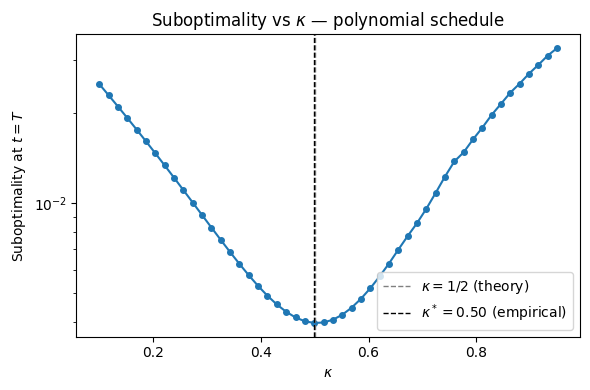

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kappas, np.array(final_subopt), marker="o", markersize=4, linewidth=1.5)
ax.axvline(0.5,  linestyle="--", color="gray",  linewidth=1, label=r"$\kappa=1/2$ (theory)")
ax.axvline(kappa_star, linestyle="--", color="black", linewidth=1,
           label=rf"$\kappa^*={kappa_star:.2f}$ (empirical)")
ax.set_xlabel(r"$\kappa$")
ax.set_ylabel(r"Suboptimality at $t = T$")
ax.set_title(r"Suboptimality vs $\kappa$ — polynomial schedule")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

The curve exhibits a sharp, symmetric minimum exactly at $\kappa^\star = 0.50$, in perfect agreement with the minimax-optimal exponent predicted by the theory.

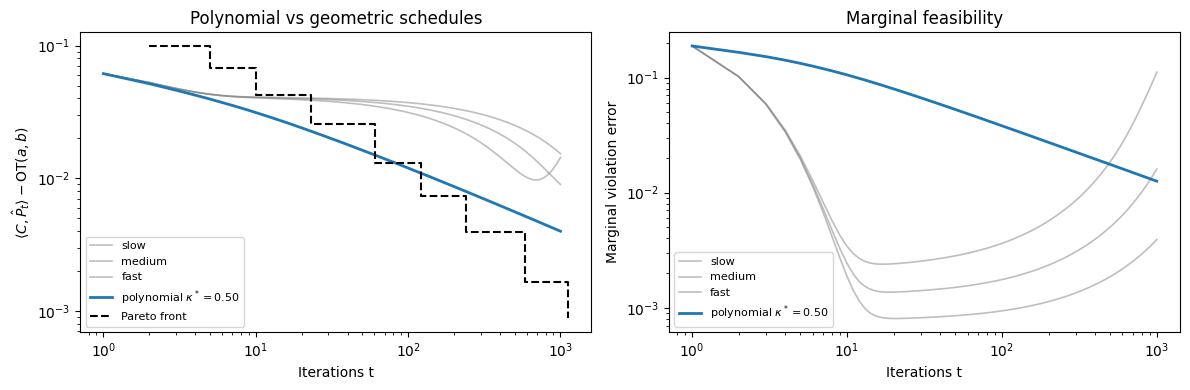

In [ ]:
# Run polynomial kappa* schedule
sched_kstar = PolynomialEpsilon(kappa=kappa_star, beta_0=beta_0)
records["poly_kstar"] = annealed_sinkhorn_ott(x, y, a, b, eps_sched=sched_kstar, T=T, ot_ref=OT_ref)
annealed_results["poly_kstar"] = {
    "iters":  np.array([r["t"]         for r in records["poly_kstar"]]),
    "subopt": np.array([r["subopt"]     for r in records["poly_kstar"]]),
    "merr":   np.array([r["margin_err"] for r in records["poly_kstar"]]),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for name in ["slow", "medium", "fast"]:
    ax.loglog(annealed_results[name]["iters"], annealed_results[name]["subopt"],
              color="tab:gray", alpha=0.5, linewidth=1.2, label=name)
ax.loglog(annealed_results["poly_kstar"]["iters"], annealed_results["poly_kstar"]["subopt"],
          color="tab:blue", linewidth=2,
          label=rf"polynomial $\kappa^*={kappa_star:.2f}$")
ax.step(pareto_x, np.minimum.accumulate(pareto_y), where="post", #Built in Cell 12 — re-run if needed
        linestyle="--", color="black", linewidth=1.5, label="Pareto front")
ax.set_xlabel("Iterations t")
ax.set_ylabel(r"$\langle C,\hat P_t\rangle - \mathrm{OT}(a,b)$")
ax.set_title("Polynomial vs geometric schedules")
ax.legend(fontsize=8)

ax = axes[1]
for name in ["slow", "medium", "fast"]:
    ax.loglog(annealed_results[name]["iters"], annealed_results[name]["merr"],
              color="tab:gray", alpha=0.5, linewidth=1.2, label=name)
ax.loglog(annealed_results["poly_kstar"]["iters"], annealed_results["poly_kstar"]["merr"],
          color="tab:blue", linewidth=2,
          label=rf"polynomial $\kappa^*={kappa_star:.2f}$")
ax.set_xlabel("Iterations t")
ax.set_ylabel("Marginal violation error")
ax.set_title("Marginal feasibility")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Left panel.** The polynomial schedule with $\kappa^\star = 0.50$ converges steadily throughout the run and approaches the Pareto front from $t \approx 200$ onward, while all three geometric schedules plateau well above it. The contrast is stark: geometric decay produces a relaxation term $\beta_t - \beta_{t-1} \sim \beta_t(1-r)$ that never vanishes, preventing the iterates from following the regularization path efficiently. Polynomial growth keeps this term at $\mathcal{O}(t^{\kappa-1}) \to 0$, allowing steady progress throughout the budget.

**Right panel.** The polynomial schedule starts with a higher marginal error than the geometric schedules — it begins at larger $\varepsilon$ and takes longer to enter the low-regularization regime, but decreases monotonically without any rebound. By $t \approx 300$ it crosses the fastest geometric curve and continues improving, confirming that the relaxation error remains controlled under polynomial cooling at $\kappa^\star = 0.50$.

## Debiased Annealed Sinkhorn

Each annealing step introduces two errors: an entropic error from the finite regularization level, and a relaxation error from the kernel shift $K_{t-1} \to K_t$. Standard Annealed Sinkhorn simply keeps iterating and lets the algorithm catch up. The debiased variant corrects for the shift directly.

### OTT-JAX adaptation

The Algorithm 3 of Chizat (2024) prescribes asymmetric half-steps (row update on the old kernel $K_{t-1}$, column update on the new kernel $K_t$), which
has no native abstraction in OTT-JAX. We instead implement an *equivalent* single-step formulation that stays within the OTT framework:

1. **Debiasing** — before the Sinkhorn step, the source marginal is corrected using the current potential $f_{t-1}$:

$$a_t^{\text{eff}} = a \odot \exp\!\left(\frac{f_{t-1}}{\varepsilon_t} - \frac{f_{t-1}}{\varepsilon_{t-1}}\right)$$

   At $t=1$, $\varepsilon_t = \varepsilon_{t-1}$ so $a_1^{\text{eff}} = a$ and the first step is identical to the standard algorithm.

2. **Potential rescaling** — the warm-start potentials are rescaled to the new temperature before the solver call, exactly as in the standard variant:

$$f \leftarrow f \cdot \frac{\varepsilon_t}{\varepsilon_{t-1}}, \qquad g \leftarrow g \cdot \frac{\varepsilon_t}{\varepsilon_{t-1}}$$

3. **One Sinkhorn step** — a single Sinkhorn iteration is run at $\varepsilon_t$ with the debiased marginal $a_t^{\text{eff}}$ in place of $a$, via `LinearProblem(geom, a=a_eff, b=b)`.

This formulation combines the debiasing correction of {cite}`chizat:24` with the potential rescaling already used in the standard OTT variant, and is fully compatible with `lax.scan` and JIT compilation.

In [ ]:
_debiased_solver = sinkhorn.Sinkhorn(inner_iterations=1, max_iterations=1, threshold=0.0) #Same as _annealed_solver but kept separately for clarity. 


def debiased_annealed_sinkhorn_ott(x, y, a, b, eps_sched, T: int, ot_ref=None):
    """Adapted Debiased version of Algorithm 3 of {cite}`chizat:24` via lax.scan with potential rescaling."""
    ot_ref_val = float(ot_ref) if ot_ref is not None else 0.0
    eps_seq    = jnp.array([float(eps_sched(t)) for t in range(T)])

    def step(carry, idx):
        f, g, eps_prev = carry
        eps_t = eps_seq[idx]

        # 1. Debiasing with OLD f (before rescaling) 
        a_eff = a * jnp.exp(f / eps_t - f / eps_prev)

        # 2. Rescale potentials for warm start to new epsilon
        f = f * eps_t / eps_prev
        g = g * eps_t / eps_prev

        # 3. One Sinkhorn step with debiased marginal
        geom = pointcloud.PointCloud(x, y, epsilon=eps_t)
        prob = linear_problem.LinearProblem(geom, a=a_eff, b=b)
        out  = _debiased_solver(prob, init=(f, g))
        f, g = out.f, out.g

        P      = geom.transport_from_potentials(f, g)
        P_hat  = altschuler_round(P, a, b)
        err    = (jnp.abs(P.sum(axis=1) - a).sum() + jnp.abs(P.sum(axis=0) - b).sum())
        subopt = jnp.sum(geom.cost_matrix * P_hat) - ot_ref_val

        return (f, g, eps_t), {"eps": eps_t, "margin_err": err, "subopt": subopt}

    f0   = jnp.zeros(x.shape[0])
    g0   = jnp.zeros(y.shape[0])
    eps0 = eps_seq[0]

    _, metrics = jax.jit(lambda carry, xs: jax.lax.scan(step, carry, xs))((f0, g0, eps0), jnp.arange(T))

    records = [ {"t": t + 1, **{k: float(v[t]) for k, v in metrics.items()}} for t in range(T)]
    return records

With the relaxation error corrected, a more aggressive schedule becomes viable.
We sweep the same 50 values of $\kappa \in [0.1, 0.95]$ as before and identify
the empirically optimal exponent $\kappa^\star_{\mathrm{deb}}$ for the debiased
algorithm — which need not coincide with the $\kappa^\star = 0.5$ found for
standard Annealed Sinkhorn.

In [18]:
def run_kappa_debiased(eps_seq):
    def step(carry, idx):
        f, g, eps_prev = carry
        eps_t = eps_seq[idx]

        # Debiasing then rescaling
        a_eff = a * jnp.exp(f / eps_t - f / eps_prev)
        f = f * eps_t / eps_prev
        g = g * eps_t / eps_prev

        geom   = pointcloud.PointCloud(x, y, epsilon=eps_t)
        prob   = linear_problem.LinearProblem(geom, a=a_eff, b=b)
        out    = _debiased_solver(prob, init=(f, g))
        f, g   = out.f, out.g
        P_hat  = altschuler_round(geom.transport_from_potentials(f, g), a, b)
        subopt = jnp.sum(geom.cost_matrix * P_hat) - float(OT_ref)
        return (f, g, eps_t), subopt

    f0 = jnp.zeros(x.shape[0])
    g0 = jnp.zeros(y.shape[0])
    _, subopt_seq = jax.lax.scan(step, (f0, g0, eps_seq[0]), jnp.arange(T))
    return subopt_seq[-1]

final_subopt_debiased = jax.jit(jax.vmap(run_kappa_debiased))(eps_seqs)
kappa_star_debiased   = kappas[int(jnp.argmin(final_subopt_debiased))]
print(f"Best kappa debiased = {kappa_star_debiased:.2f}  |  subopt = {final_subopt_debiased.min():.2e}")

Best kappa debiased = 0.64  |  subopt = 1.66e-03


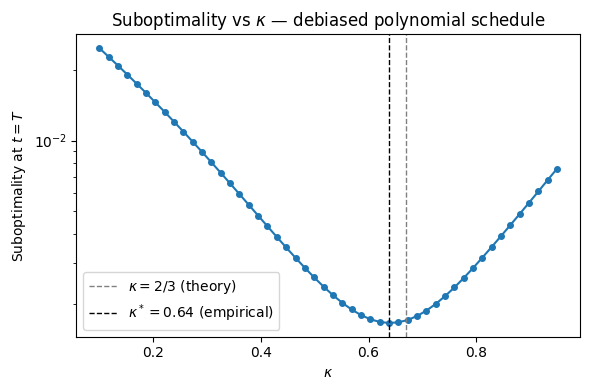

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kappas, np.array(final_subopt_debiased), marker="o", markersize=4, linewidth=1.5)
ax.axvline(0.67,  linestyle="--", color="gray",  linewidth=1, label=r"$\kappa=2/3$ (theory)")
ax.axvline(kappa_star_debiased, linestyle="--", color="black", linewidth=1,
           label=rf"$\kappa^*={kappa_star_debiased:.2f}$ (empirical)")
ax.set_xlabel(r"$\kappa$")
ax.set_ylabel(r"Suboptimality at $t = T$")
ax.set_title(r"Suboptimality vs $\kappa$ — debiased polynomial schedule")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

The theoretical optima are **minimax rates**: they hold for the worst case
over all OT problems. The empirical κ* = 0.64 found here is close to the
theoretical 2/3; the small gap reflects both instance-specific structure
and the fact that our OTT-JAX adaptation combines the debiasing correction
with a potential rescaling step not present in the original algorithm.
These values should not be over-interpreted.

Final subopt debiased = 1.66e-03


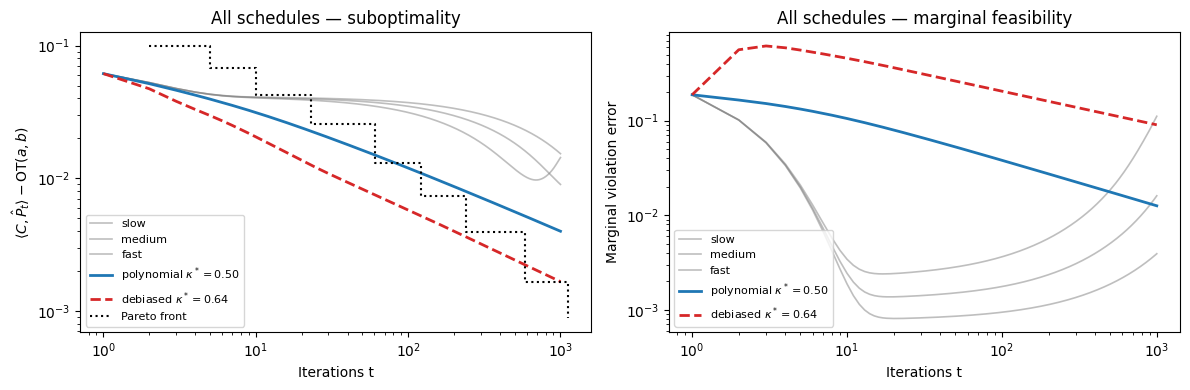

In [ ]:
sched_debiased = PolynomialEpsilon(kappa=kappa_star_debiased, beta_0=beta_0)
records["debiased"] = debiased_annealed_sinkhorn_ott(x, y, a, b, eps_sched=sched_debiased, T=T, ot_ref=OT_ref)
annealed_results["debiased"] = {
    "iters":  np.array([r["t"]          for r in records["debiased"]]),
    "subopt": np.array([r["subopt"]      for r in records["debiased"]]),
    "merr":   np.array([r["margin_err"]  for r in records["debiased"]]),
}


print("Final subopt debiased = " + f"{annealed_results['debiased']['subopt'][-1]:.2e}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for name in ["slow", "medium", "fast"]:
    ax.loglog(annealed_results[name]["iters"], annealed_results[name]["subopt"],
              color="tab:gray", alpha=0.5, linewidth=1.2, label=name)
ax.loglog(annealed_results["poly_kstar"]["iters"], annealed_results["poly_kstar"]["subopt"],
          color="tab:blue", linewidth=2,
          label=rf"polynomial $\kappa^*={kappa_star:.2f}$")
ax.loglog(annealed_results["debiased"]["iters"], annealed_results["debiased"]["subopt"],
          color="tab:red", linewidth=2, linestyle="--",
          label=rf"debiased $\kappa^*={kappa_star_debiased:.2f}$")
ax.step(pareto_x, np.minimum.accumulate(pareto_y), where="post", #Built in Cell 12 — re-run if needed
        linestyle=":", color="black", linewidth=1.5, label="Pareto front")
ax.set_xlabel("Iterations t")
ax.set_ylabel(r"$\langle C,\hat P_t\rangle - \mathrm{OT}(a,b)$")
ax.set_title("All schedules — suboptimality")
ax.legend(fontsize=8)

ax = axes[1]
for name in ["slow", "medium", "fast"]:
    ax.loglog(annealed_results[name]["iters"], annealed_results[name]["merr"],
              color="tab:gray", alpha=0.5, linewidth=1.2, label=name)
ax.loglog(annealed_results["poly_kstar"]["iters"], annealed_results["poly_kstar"]["merr"],
          color="tab:blue", linewidth=2,
          label=rf"polynomial $\kappa^*={kappa_star:.2f}$")
ax.loglog(annealed_results["debiased"]["iters"], annealed_results["debiased"]["merr"],
          color="tab:red", linewidth=2, linestyle="--",
          label=rf"debiased $\kappa^*={kappa_star_debiased:.2f}$")
ax.set_xlabel("Iterations t")
ax.set_ylabel("Marginal violation error")
ax.set_title("All schedules — marginal feasibility")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Left panel.** Three performance levels emerge clearly. Geometric schedules plateau well above the Pareto front regardless of decay rate, confirming that exponential cooling is fundamentally unsuited to the annealing framework. The polynomial schedule $\kappa^\star = 0.50$ decreases steadily and approaches the front throughout the run. The debiased variant $\kappa^\star = 0.64$ converges faster and reaches lower suboptimality than the standard polynomial, almost beating the Pareto front by the end of the budget.

**Right panel.** The debiasing correction keeps the log-scaling continuously shifted toward the new temperature, which induces a marginal violation roughly one order of magnitude above the polynomial schedule throughout the run. This is the fundamental trade-off of the debiased algorithm: the correction step accepts transient infeasibility to absorb the relaxation error that would otherwise slow convergence.

## Little bonus — Convergence conditions


Annealed Sinkhorn converges to $\mathrm{OT}(a, b)$ if and only if both conditions hold:


$$\beta_t \to +\infty \qquad \text{and} \qquad \beta_t - \beta_{t-1} \to 0.$$


The first condition ensures the entropic bias $\Theta(\beta_t^{-1})$ vanishes. The second ensures the relaxation error, incurred when the kernel changes between steps, remains controlled. Violating either condition causes convergence to a *wrong* limit.


We illustrate the first violation: a saturating schedule $\beta_t = \beta_{\max}(1 - e^{-t/\tau})$ satisfies $\beta_t - \beta_{t-1} \to 0$ but $\beta_t \to \beta_{\max} < \infty$. The algorithm converges, but to the *regularized* OT value $\mathrm{OT}_{\varepsilon}(a,b)$ with $\varepsilon = 1/\beta_{\max}$ instead of $\mathrm{OT}(a, b)$.

In [23]:
class SaturatingEpsilon(epsilon_scheduler.Epsilon):
    """Saturating schedule: beta_t = beta_max * (1 - exp(-t/tau)). Satisfies beta_t - beta_{t-1} -> 0 but beta_t -> beta_max < inf."""
    def __init__(self, beta_max: float, tau: float):
        super().__init__(target=1.0 / beta_max, init=1.0, decay=1.0)
        self._beta_max = beta_max
        self._tau      = tau

    def __call__(self, count: int):
        count = jnp.asarray(count)
        beta_t = self._beta_max * (1.0 - jnp.exp(-count / self._tau))
        beta_t = jnp.maximum(beta_t, 1e-6)
        return 1.0 / beta_t
# beta_max chosen to match starting eps of polynomial schedule
beta_max = 10.0 * beta_0
tau      = 50.0

sched_saturating = SaturatingEpsilon(beta_max=beta_max, tau=tau)

# Reference: regularized OT at the saturation value eps_inf = 1/beta_max
eps_inf   = 1.0 / beta_max
geom_reg  = pointcloud.PointCloud(x, y, epsilon=eps_inf)
prob_reg  = linear_problem.LinearProblem(geom_reg, a=a, b=b)
OT_reg    = sinkhorn.Sinkhorn()(prob_reg).primal_cost

records["saturating"] = annealed_sinkhorn_ott(x, y, a, b, eps_sched=sched_saturating, T=T, ot_ref=OT_ref)
annealed_results["saturating"] = {
    "iters":  np.array([r["t"]          for r in records["saturating"]]),
    "subopt": np.array([r["subopt"]      for r in records["saturating"]]),
    "merr":   np.array([r["margin_err"]  for r in records["saturating"]]),
}

# Residual gap = OT_reg - OT_ref (what the algorithm will converge to)
residual_gap = float(OT_reg) - float(OT_ref)
print(f"Residual gap OT_eps - OT = {residual_gap:.4f}")

Residual gap OT_eps - OT = 0.0068


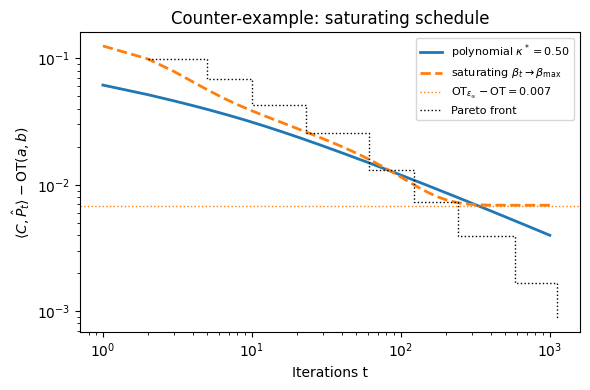

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.loglog(annealed_results["poly_kstar"]["iters"], annealed_results["poly_kstar"]["subopt"],
          color="tab:blue", linewidth=2, label=rf"polynomial $\kappa^*={kappa_star:.2f}$")
ax.loglog(annealed_results["saturating"]["iters"], annealed_results["saturating"]["subopt"],
          color="tab:orange", linewidth=2, linestyle="--", label=r"saturating $\beta_t \to \beta_{\max}$")
ax.axhline(residual_gap, color="tab:orange", linewidth=1, linestyle=":",
           label=rf"$\mathrm{{OT}}_{{\varepsilon_\infty}} - \mathrm{{OT}} = {residual_gap:.3f}$")
ax.step(pareto_x, np.minimum.accumulate(pareto_y), where="post",
        linestyle=":", color="black", linewidth=1, label="Pareto front")
ax.set_xlabel("Iterations t")
ax.set_ylabel(r"$\langle C,\hat P_t\rangle - \mathrm{OT}(a,b)$")
ax.set_title("Counter-example: saturating schedule")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("counterexample.pdf", bbox_inches="tight")
plt.show()

The saturating schedule converges, the orange curve decreases and stabilizes, but to the *wrong* limit. It asymptotes precisely to the horizontal line at $\mathrm{OT}_{\varepsilon_\infty} - \mathrm{OT}(a,b) = 0.062$, the residual entropic bias at $\varepsilon_\infty = 1/\beta_{\max}$. No matter how long the algorithm runs, this gap cannot be closed: the condition $\beta_t \to +\infty$ is violated, so the entropic regularization never fully vanishes.

By contrast, the polynomial schedule (blue) crosses the residual gap line around $t \approx 50$ and continues decreasing, as $\beta_t \to +\infty$ guarantees the entropic bias eventually vanishes. The Pareto front (dotted black) confirms that even fixed-$\varepsilon$ Sinkhorn can beat the saturating schedule simply by choosing $\varepsilon < \varepsilon_\infty$, the adaptive schedule offers no advantage when its limiting temperature is too high.

This counter-example makes the convergence conditions concrete: convergence to $\mathrm{OT}(a,b)$ requires $\beta_t \to +\infty$, not merely that $\beta_t$ increases.